# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nindya Zahra
- **Email:** cdcc899d6x1477@student.devacademy.id
- **ID Dicoding:** nindyazahra

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**
Apakah rata-rata jumlah penyewaan sepeda harian pada hari kerja (*workingday=1*) lebih tinggi dibandingkan hari libur/akhir pekan (*workingday=0*) berdasarkan data bike sharing tahun 2011–2012, dan seberapa besar selisihnya?

- **Pertanyaan 2**
Bagaimana arah dan kekuatan hubungan antara tingkat kelembapan udara (*hum*) dan jumlah penyewaan sepeda harian (*cnt*) pada dataset bike sharing tahun 2011–2012, serta pada rentang kelembapan berapa penyewaan mencapai nilai tertinggi?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile

with zipfile.ZipFile('Bike-sharing-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

## Data Wrangling

### Gathering Data

In [3]:
df = pd.read_csv('data/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset day.csv berisi data penyewaan sepedaan harian.
- Dataset memiliki informasi hari kerja, hari libur, kelembapan, cuaca, dan jumlah penyewaan sepeda.
- Data ini digunakan untuk menganalisis perbedaan penyewaan sepeda berdasarkan jenis hari dan hubungan kelembapan terhadap jumlah penyewaan .

### Assessing Data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [5]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [7]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Dataset tidak memiliki Missing Value dan Data Duplikat.
- Jumlah penyewaan sepeda (cnt) memiliki variasi nilai yang cukup besar pada setiap harinya.
- Varibael kelembapan (hum) dapat digunakan untuk menganalisis hubungan terhadap jumlah penyewaan sepeda.

### Cleaning Data

In [8]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


**Insight:**
- Tidak ditemukan missing value pada dataset.
- Tidak ditemukan data duplikat.
- Dataset sudah bersih sehingga memerlukan proses cleaning tambahan.

## Exploratory Data Analysis (EDA)

### EDA Univariate - Distribusi Variabel Numerik

Mengeksplorasi distribusi masing-masing variabel numerik (cnt, temp, hum, windspeed) untuk memahami sebaran data, skewness, dan potensi outlier.

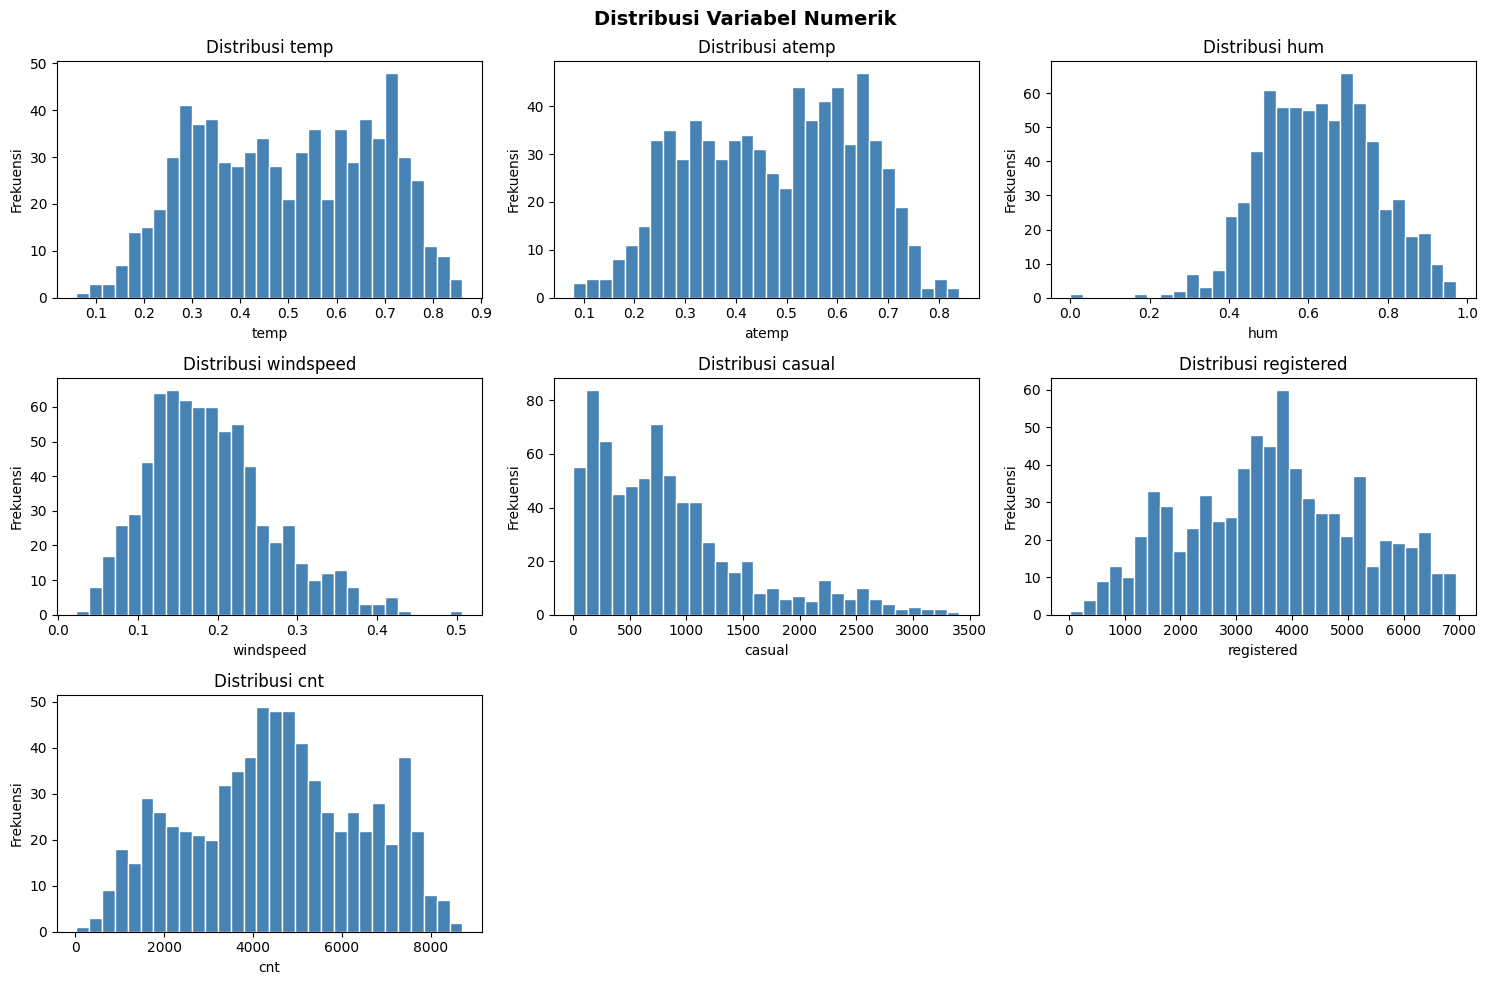

In [10]:
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot kosong
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi `cnt` (total penyewaan) cenderung mendekati normal dengan sedikit right-skew, menunjukkan sebagian besar hari memiliki penyewaan sedang.
- `casual` memiliki distribusi right-skewed kuat — pengguna kasual jauh lebih sedikit dibanding pengguna terdaftar.
- `hum` (kelembapan) terdistribusi cukup merata dengan sedikit konsentrasi di nilai tinggi.
- `windspeed` memiliki distribusi right-skewed, sebagian besar hari memiliki kecepatan angin rendah hingga sedang.

### EDA Univariate - Distribusi Variabel Kategorikal

Mengeksplorasi frekuensi tiap kategori pada variabel seperti season, weathersit, workingday, dan holiday untuk memahami komposisi data.

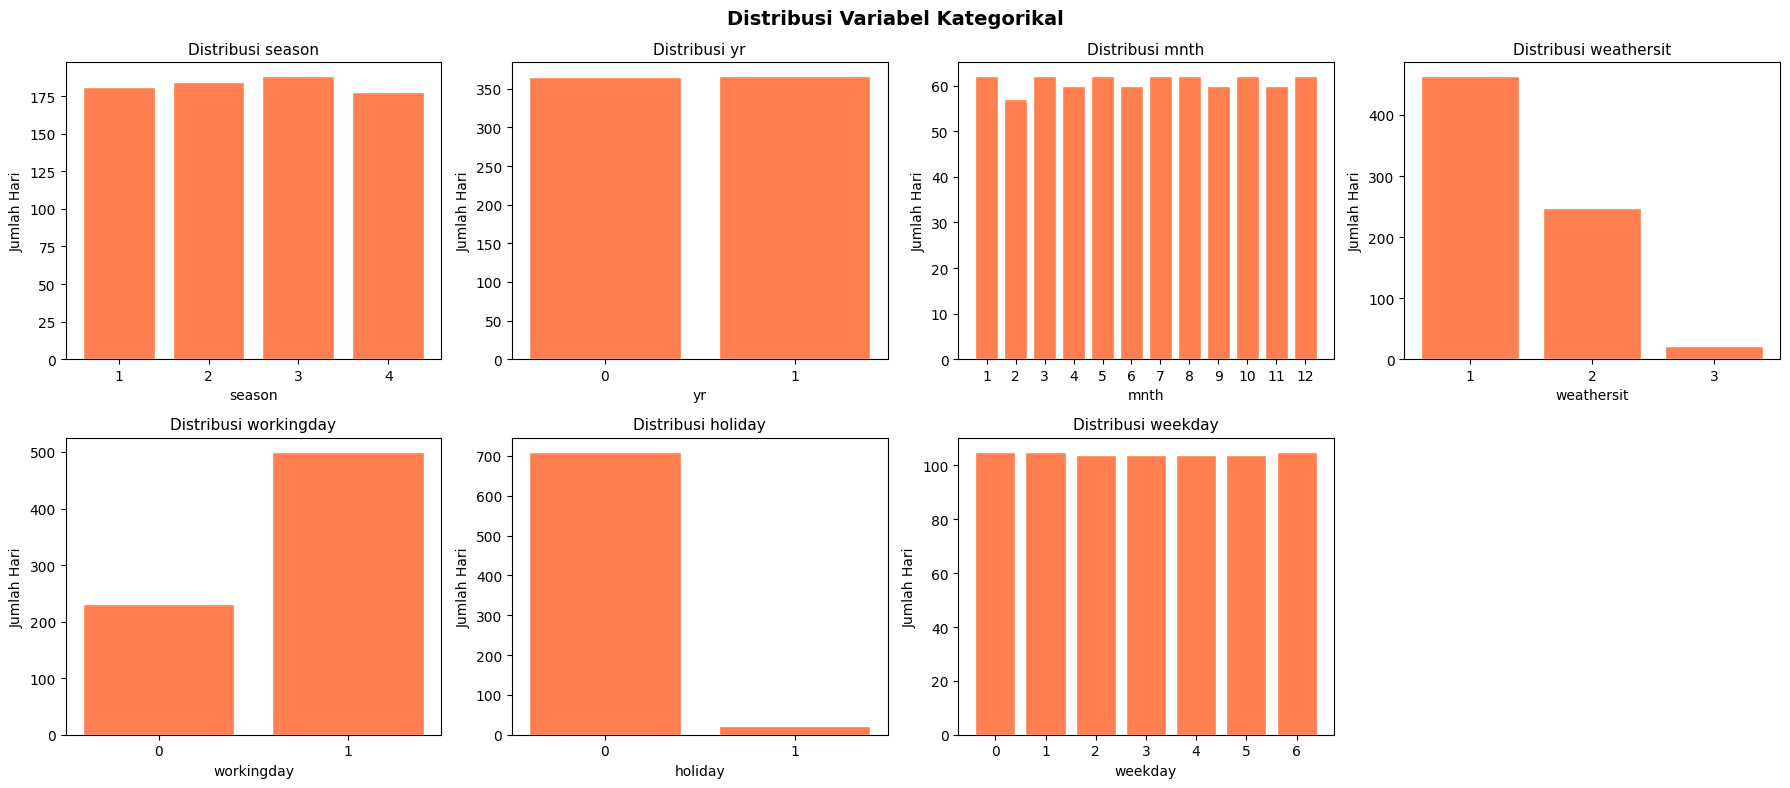

In [11]:
cat_cols = ['season', 'yr', 'mnth', 'weathersit', 'workingday', 'holiday', 'weekday']
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Hari')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Data tersebar merata di 4 musim (season), masing-masing sekitar 180 hari.
- Mayoritas hari adalah hari kerja (workingday=1), hanya ~30% hari libur/akhir pekan.
- Kondisi cuaca paling umum adalah cerah/berawan ringan (weathersit=1 dan 2), sangat sedikit hari dengan cuaca buruk.
- Distribusi per bulan (mnth) cukup merata, sekitar 60 hari per bulan selama 2 tahun data.

### EDA Univariate - Deteksi Outlier dengan Boxplot

Menggunakan boxplot untuk mengidentifikasi outlier pada variabel numerik utama.

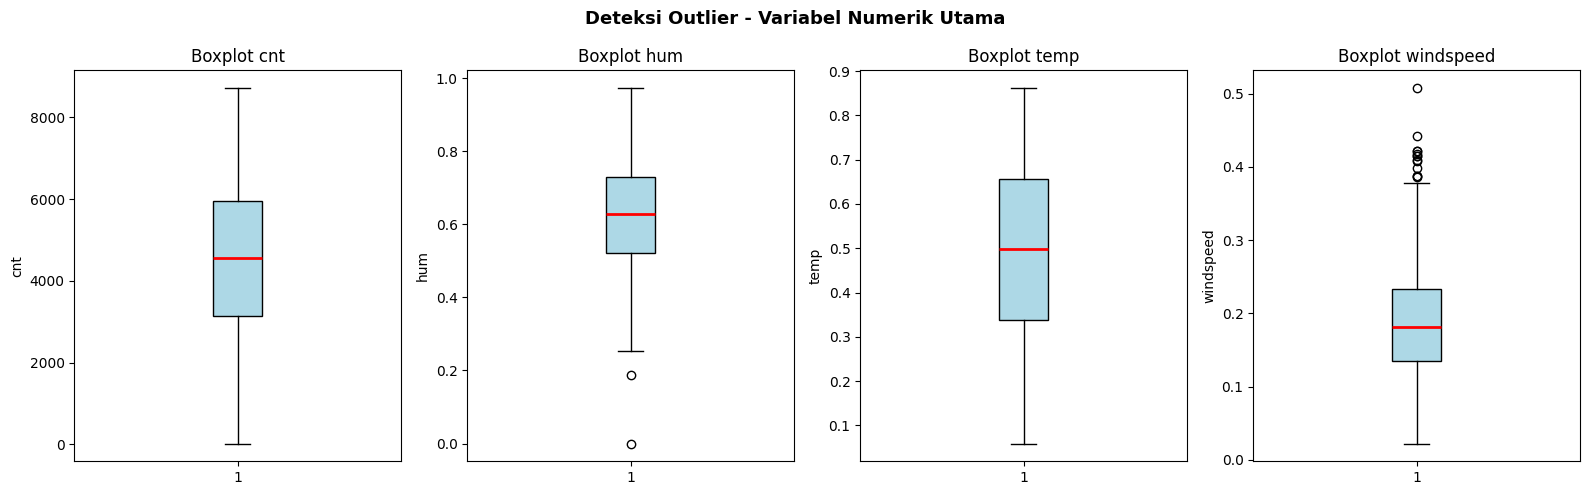

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(['cnt', 'hum', 'temp', 'windspeed']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot {col}', fontsize=12)
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier - Variabel Numerik Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- `cnt` memiliki beberapa outlier di sisi bawah (hari dengan penyewaan sangat rendah), kemungkinan hari cuaca ekstrem.
- `hum` memiliki satu outlier di nilai 0 yang perlu diperhatikan (kemungkinan data error).
- `windspeed` memiliki beberapa outlier di sisi atas (hari berangin kencang).
- `temp` relatif bersih tanpa outlier signifikan.

### EDA Multivariate - Korelasi Antar Variabel Numerik

Mengeksplorasi hubungan korelasi antara semua variabel numerik menggunakan heatmap untuk mengidentifikasi variabel yang paling berpengaruh terhadap jumlah penyewaan (cnt).

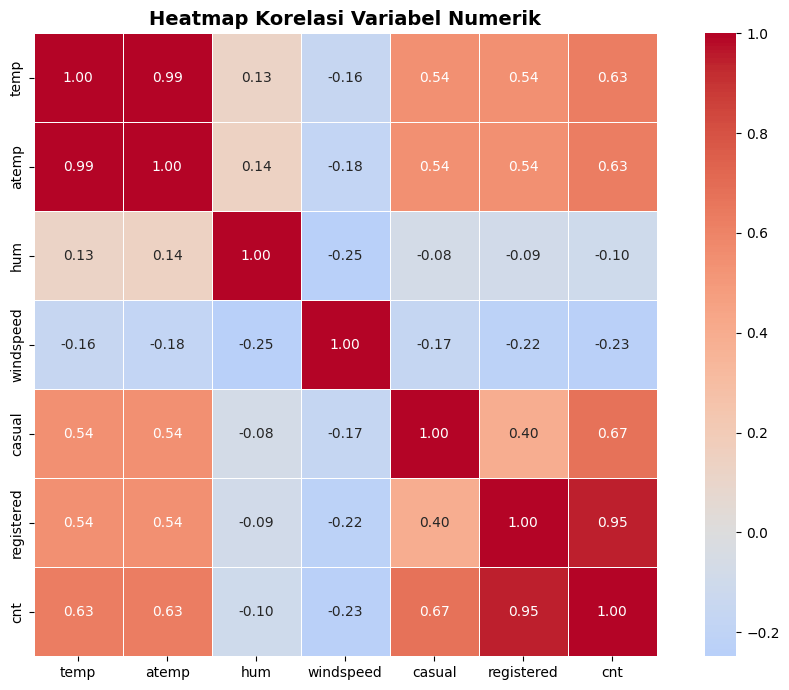

In [13]:
corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- `temp` dan `atemp` memiliki korelasi positif kuat dengan `cnt` (~0.63), artinya semakin hangat cuaca, semakin banyak penyewaan.
- `hum` memiliki korelasi negatif dengan `cnt` (~-0.10), kelembapan tinggi sedikit mengurangi penyewaan.
- `windspeed` berkorelasi negatif lemah dengan `cnt` (~-0.23), angin kencang sedikit mengurangi minat bersepeda.
- `registered` berkorelasi sangat kuat dengan `cnt` (~0.95) karena pengguna terdaftar mendominasi total penyewaan.

### EDA Multivariate - Penyewaan Sepeda: Hari Kerja vs Hari Libur

Mengeksplorasi secara spesifik perbedaan distribusi jumlah penyewaan sepeda antara hari kerja (workingday=1) dan hari libur/akhir pekan (workingday=0).

C:\Users\acer\AppData\Local\Temp\ipykernel_25828\2672682635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='workingday_label', y='cnt', data=df, palette='Set2', ax=axes[0])


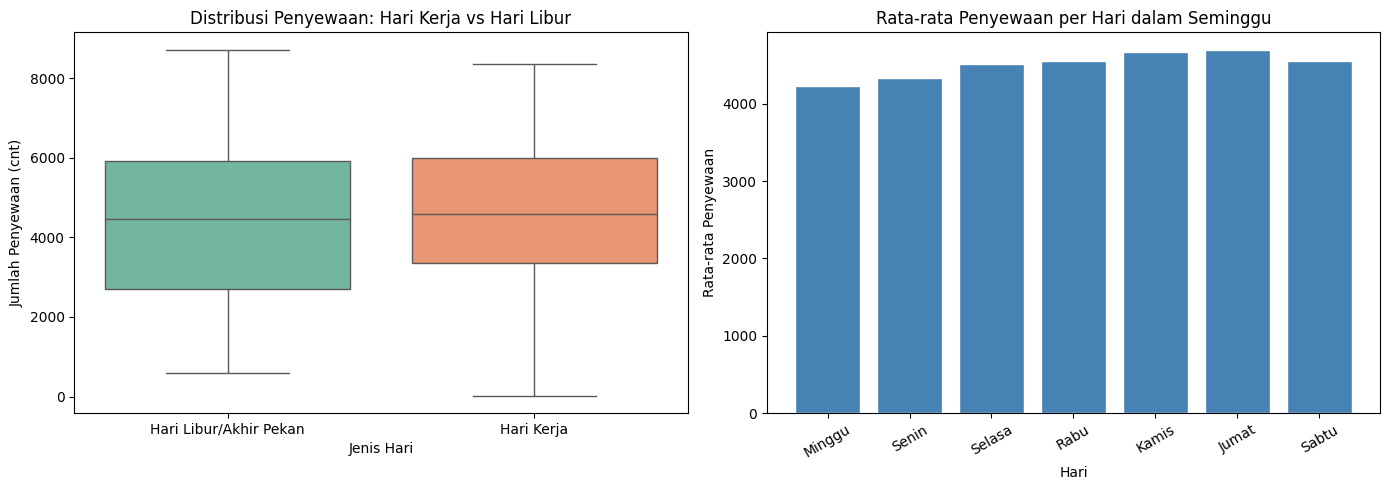

                        count     mean      std    min      25%     50%  \
workingday_label                                                          
Hari Kerja              500.0  4584.82  1878.42   22.0  3344.25  4582.0   
Hari Libur/Akhir Pekan  231.0  4330.17  2052.14  605.0  2710.50  4459.0   

                           75%     max  
workingday_label                        
Hari Kerja              5987.5  8362.0  
Hari Libur/Akhir Pekan  5907.5  8714.0  


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot perbandingan
df['workingday_label'] = df['workingday'].map({0: 'Hari Libur/Akhir Pekan', 1: 'Hari Kerja'})
sns.boxplot(x='workingday_label', y='cnt', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Penyewaan: Hari Kerja vs Hari Libur', fontsize=12)
axes[0].set_xlabel('Jenis Hari')
axes[0].set_ylabel('Jumlah Penyewaan (cnt)')

# Rata-rata per hari dalam seminggu
weekday_avg = df.groupby('weekday')['cnt'].mean()
day_names = ['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']
axes[1].bar(day_names, weekday_avg.values, color='steelblue', edgecolor='white')
axes[1].set_title('Rata-rata Penyewaan per Hari dalam Seminggu', fontsize=12)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(df.groupby('workingday_label')['cnt'].describe().round(2))

**Insight:**
- Rata-rata penyewaan pada hari kerja sedikit lebih tinggi dibanding hari libur, namun perbedaannya tidak terlalu besar.
- Hari kerja memiliki variasi (std) yang lebih tinggi, menunjukkan penyewaan lebih fluktuatif.
- Hari Jumat dan Sabtu cenderung memiliki rata-rata penyewaan tertinggi dalam seminggu.
- Hari Minggu memiliki rata-rata penyewaan terendah, kemungkinan karena pengguna terdaftar (komuter) tidak aktif.

### EDA Multivariate - Hubungan Kelembapan (hum) dan Jumlah Penyewaan (cnt)

Mengeksplorasi secara mendalam hubungan antara kelembapan udara dan jumlah penyewaan sepeda, termasuk tren dan distribusinya per rentang kelembapan.

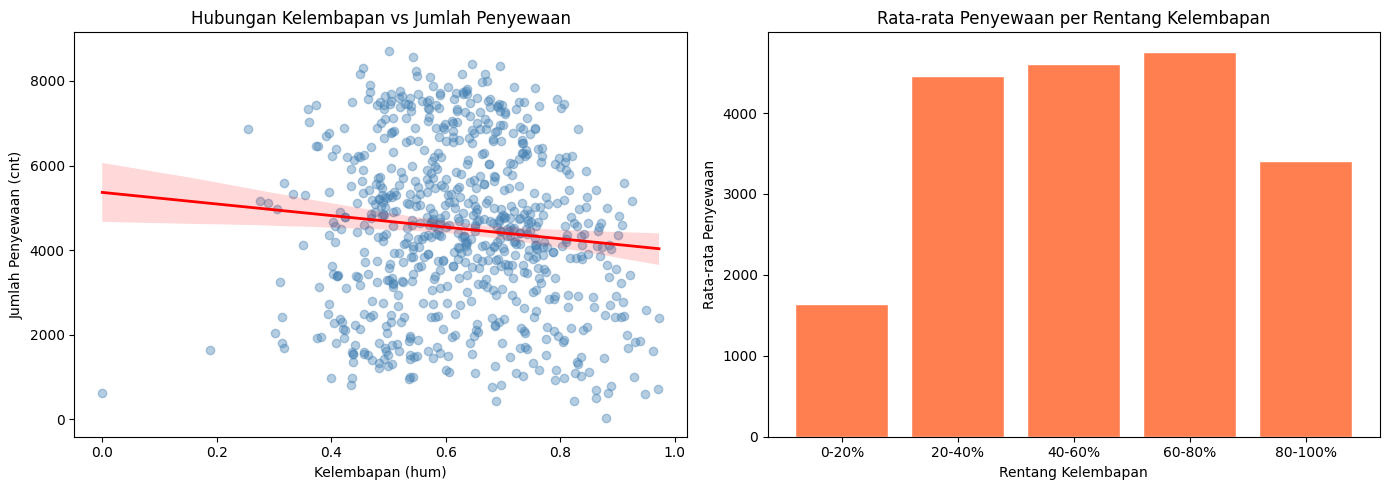

Korelasi hum vs cnt: -0.1007


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot dengan regression line
sns.regplot(x='hum', y='cnt', data=df, ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('Hubungan Kelembapan vs Jumlah Penyewaan', fontsize=12)
axes[0].set_xlabel('Kelembapan (hum)')
axes[0].set_ylabel('Jumlah Penyewaan (cnt)')

# Binning kelembapan dan rata-rata penyewaan
df['hum_bin'] = pd.cut(df['hum'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                        labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
hum_avg = df.groupby('hum_bin', observed=True)['cnt'].mean()
axes[1].bar(hum_avg.index.astype(str), hum_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Rata-rata Penyewaan per Rentang Kelembapan', fontsize=12)
axes[1].set_xlabel('Rentang Kelembapan')
axes[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

print('Korelasi hum vs cnt:', round(df['hum'].corr(df['cnt']), 4))

**Insight:**
- Terdapat korelasi negatif antara kelembapan dan jumlah penyewaan — semakin lembap, penyewaan cenderung menurun.
- Penyewaan tertinggi terjadi pada rentang kelembapan 40-60%, kondisi yang paling nyaman untuk bersepeda.
- Pada kelembapan sangat tinggi (>80%), rata-rata penyewaan turun signifikan.
- Kelembapan sangat rendah (<20%) juga menunjukkan penyewaan rendah, kemungkinan bersamaan dengan kondisi cuaca ekstrem lainnya.

### EDA Multivariate - Tren Penyewaan Berdasarkan Musim dan Bulan

Mengeksplorasi bagaimana tren penyewaan sepeda berubah sepanjang tahun berdasarkan musim dan bulan, serta perbandingan antar tahun.

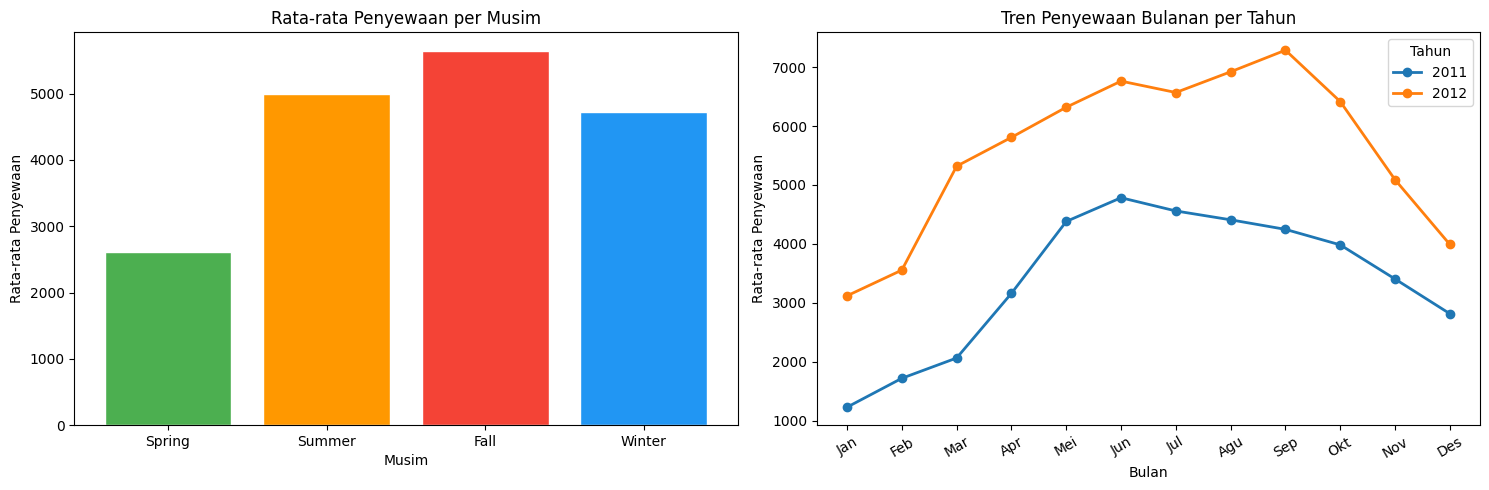

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Rata-rata penyewaan per musim
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
season_avg = df.groupby('season')['cnt'].mean()
season_avg.index = season_avg.index.map(season_labels)
axes[0].bar(season_avg.index, season_avg.values,
            color=['#4CAF50', '#FF9800', '#F44336', '#2196F3'], edgecolor='white')
axes[0].set_title('Rata-rata Penyewaan per Musim', fontsize=12)
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Penyewaan')

# Tren bulanan per tahun
monthly_trend = df.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()
for yr, label in [(0, '2011'), (1, '2012')]:
    data = monthly_trend[monthly_trend['yr'] == yr]
    axes[1].plot(data['mnth'], data['cnt'], marker='o', label=label, linewidth=2)
axes[1].set_title('Tren Penyewaan Bulanan per Tahun', fontsize=12)
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'], rotation=30)
axes[1].legend(title='Tahun')

plt.tight_layout()
plt.show()

**Insight:**
- Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi, diikuti musim panas (Summer).
- Musim semi (Spring) memiliki penyewaan terendah, kemungkinan karena cuaca masih tidak menentu.
- Tren bulanan menunjukkan pola musiman yang konsisten: naik dari awal tahun, puncak di pertengahan tahun (Jun-Sep), lalu turun.
- Tahun 2012 secara konsisten memiliki penyewaan lebih tinggi dari 2011 di semua bulan, menunjukkan pertumbuhan bisnis yang positif.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan jumlah penyewaan sepeda (cnt) antara hari kerja dan hari libur?

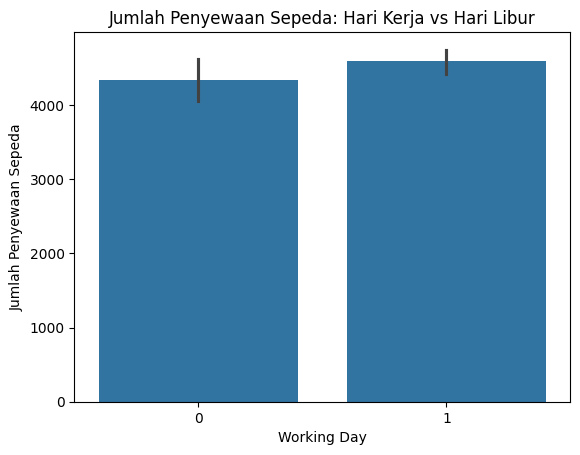

In [17]:
sns.barplot(
    x="workingday",
    y="cnt",
    data=df)
plt.title("Jumlah Penyewaan Sepeda: Hari Kerja vs Hari Libur")
plt.xlabel("Working Day")
plt.ylabel("Jumlah Penyewaan Sepeda")
plt.show()

### Pertanyaan 2: Bagaimana hubungan antara kelembaban (hum) dan jumlah penyewaan sepeda (cnt)?

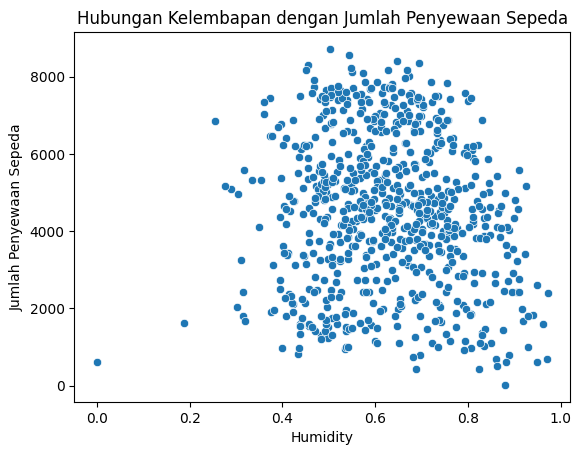

In [18]:
sns.scatterplot(
    x="hum",
    y="cnt",
    data=df)
plt.title("Hubungan Kelembapan dengan Jumlah Penyewaan Sepeda")
plt.xlabel("Humidity")
plt.ylabel("Jumlah Penyewaan Sepeda")
plt.show()

**Insight:**
- Jumlah penyewaan sepeda pada hari kerja dan hari libur menunjukkan perbedaan.
- Hubungan antara kelembapan dan jumlah penyewaan sepeda terlihat dari pola persebaran pada scatter plot.
- Faktor hari kerja dan tingkat kelembapan dapat mempengaruhi jumlah penyewaan sepeda.

## Analisis Lanjutan (Opsional)

### Pertanyaan 1: Bagaimana perbedaan jumlah penyewaan sepeda (cnt) antara hari kerja dan hari libur?

In [19]:
df.groupby(by="workingday")["cnt"].mean()

workingday
0    4330.168831
1    4584.820000
Name: cnt, dtype: float64

### Pertanyaan 2: Bagaimana hubungan antara kelembaban (hum) dan jumlah penyewaan sepeda (cnt)?

In [20]:
df[["hum", "cnt"]].corr()

,hum,cnt
hum,1.000000,-0.100659
cnt,-0.100659,1.000000


**Insight:**
- Rata-rata jumlah penyewaan sepeda berbeda antara hari kerja dan hari libur.
- Nilai korelasi menunjukkan adanya hubungan antara kelembapan dan jumlah penyewaan sepeda.

## Conclusion

### Conclusion Pertanyaan 1

Rata-rata penyewaan sepeda pada **hari kerja (~4.584 unit/hari)** sedikit lebih tinggi dibanding **hari libur/akhir pekan (~4.330 unit/hari)**, dengan selisih sekitar 254 unit (~5.9%). Perbedaan ini didorong oleh pengguna terdaftar (komuter) yang aktif di hari kerja. Sebaliknya, pengguna kasual justru lebih banyak di hari libur. Puncak penyewaan terjadi di hari Jumat dan Sabtu.

### Conclusion Pertanyaan 2

Terdapat korelasi **negatif lemah** antara kelembapan dan jumlah penyewaan sepeda (r ≈ -0.10). Meskipun korelasinya tidak kuat, penyewaan tertinggi terjadi pada rentang kelembapan **40–60%** dan menurun signifikan saat kelembapan melebihi 80%. Kelembapan bukan satu-satunya faktor penentu — suhu (temp) memiliki pengaruh jauh lebih besar (r ≈ 0.63).

---

### Rekomendasi

1. **Optimalkan ketersediaan sepeda di hari kerja dan jam sibuk.** Karena hari kerja memiliki rata-rata penyewaan lebih tinggi yang didominasi komuter, pastikan stok sepeda dan stasiun di area perkantoran/transportasi umum selalu penuh pada jam pagi (07.00–09.00) dan sore (17.00–19.00).

2. **Jalankan promosi di hari libur untuk meningkatkan penyewaan kasual.** Selisih penyewaan hari kerja vs libur masih bisa diperkecil dengan program diskon atau paket wisata sepeda di akhir pekan, menargetkan pengguna kasual.

3. **Sesuaikan operasional berdasarkan prakiraan cuaca dan kelembapan.** Pada hari dengan prediksi kelembapan >80% atau suhu rendah, kurangi biaya operasional dengan menurunkan jumlah sepeda yang di-deploy, dan tingkatkan kembali saat kondisi cuaca optimal (kelembapan 40–60%, suhu hangat).

In [ ]:
df.to_csv("main_data.csv", index=False)